# PHẦN 2A: HUẤN LUYỆN & ĐÁNH GIÁ MÔ HÌNH BASELINE (LOGISTIC REGRESSION)
## GIAO THỨC 10-RUN PROTOCOL & TỐI ƯU HÓA NGƯỠNG YOUDEN'S J
---
**Mục tiêu:**
1. Đọc dữ liệu đã chuẩn bị từ `data/train_test/`.
2. Áp dụng **StandardScaler** và cân bằng lớp thiểu số bằng **SMOTE**.
3. Huấn luyện **Logistic Regression** với **Stratified 3-Fold Cross-Validation** (Giao thức 10 Runs).
4. Tối ưu hóa ngưỡng quyết định dựa trên **Youden's J Statistic ($J = 	ext{TPR} - 	ext{FPR}$)**.
5. Đánh giá tính ổn định thống kê ($Mean \pm Std, CV\%$) và lưu trữ artifacts vào `models/baseline/`.


In [4]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score, precision_score,
    f1_score, confusion_matrix, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# 1. Đọc dữ liệu từ data/train_test/
data_dir = os.path.join("data", "train_test")
X_train = pd.read_csv(os.path.join(data_dir, "X_train.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "y_train.csv")).values.ravel()
X_test = pd.read_csv(os.path.join(data_dir, "X_test.csv"))
y_test = pd.read_csv(os.path.join(data_dir, "y_test.csv")).values.ravel()

with open(os.path.join("models", "feature_columns.json"), "r", encoding="utf-8") as f:
    feature_cols = json.load(f)

print(f"✔ Đã nạp dữ liệu thành công: Train={X_train.shape}, Test={X_test.shape}")


✔ Đã nạp dữ liệu thành công: Train=(67678, 33), Test=(17950, 33)


---
### 2. GIAO THỨC HUẤN LUYỆN 10 RUNS ĐỘC LẬP & TỐI ƯU NGƯỠNG YOUDEN'S J


In [5]:
runs_records = []
best_run_idx = -1
best_run_auc = -1.0
best_artifacts = {}

for run_id in range(1, 11):
    seed = 42 + run_id * 7
    
    # 1. Scaling
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_train)
    X_te_scaled = scaler.transform(X_test)
    
    # 2. SMOTE on Train
    smote = SMOTE(random_state=seed)
    X_tr_res, y_tr_res = smote.fit_resample(X_tr_scaled, y_train)
    
    # 3. Model & GridSearch
    base_lr = LogisticRegression(random_state=seed, max_iter=1000)
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1.0],
        'penalty': ['l2'],
        'solver': ['liblinear', 'lbfgs'],
        'class_weight': ['balanced', None]
    }
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    grid = GridSearchCV(base_lr, param_grid, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_tr_res, y_tr_res)
    
    model = grid.best_estimator_
    
    # 4. Predict Proba on Test
    y_prob = model.predict_proba(X_te_scaled)[:, 1]
    
    # 5. Youden's J Optimization
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    opt_threshold = thresholds[opt_idx]
    
    y_pred = (y_prob >= opt_threshold).astype(int)
    
    # 6. Metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    rec_ret = recall_score(y_test, y_pred)
    rec_churn = recall_score(1 - y_test, 1 - y_pred)
    prec_ret = precision_score(y_test, y_pred, zero_division=0)
    f1_ret = f1_score(y_test, y_pred, zero_division=0)
    pred_ret_rate = np.mean(y_pred)
    
    record = {
        'run_id': run_id,
        'seed': seed,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'recall_retain': rec_ret,
        'recall_churn': rec_churn,
        'precision_retain': prec_ret,
        'f1_retain': f1_ret,
        'pred_retain_rate': pred_ret_rate,
        'youden_threshold': opt_threshold,
        'best_params': str(grid.best_params_)
    }
    runs_records.append(record)
    
    if roc_auc > best_run_auc:
        best_run_auc = roc_auc
        best_run_idx = run_id
        best_artifacts = {
            'model': model,
            'scaler': scaler,
            'params': grid.best_params_,
            'metrics': record,
            'y_prob': y_prob,
            'y_pred': y_pred
        }

# Tong hop DataFrame 10 runs
df_runs = pd.DataFrame(runs_records)
os.makedirs("models/baseline/best_run", exist_ok=True)
os.makedirs("models/baseline/current_run", exist_ok=True)

df_runs.to_csv("models/baseline/status.csv", index=False)
joblib.dump(best_artifacts['model'], "models/baseline/best_run/best_model.pkl")
joblib.dump(best_artifacts['scaler'], "models/baseline/best_run/best_scaler.pkl")
with open("models/baseline/best_run/best_params.json", "w") as f:
    json.dump(best_artifacts['params'], f, indent=2)
with open("models/baseline/best_run/best_metrics.json", "w") as f:
    json.dump(best_artifacts['metrics'], f, indent=2)

print("=== BẢNG THỐNG KÊ 10 LẦN CHẠY BASELINE MODEL ===")
stats_summary = pd.DataFrame({
    'Mean': df_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].mean(),
    'Std': df_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].std(),
    'CV (%)': (df_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].std() / 
               df_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].mean() * 100)
})
print(stats_summary.round(4))


d:\record_by_me\tdtu\Data_Analysis_and_Visualization\Midterm\fix\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\record_by_me\tdtu\Data_Analysis_and_Visualization\Midterm\fix\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of

=== BẢNG THỐNG KÊ 10 LẦN CHẠY BASELINE MODEL ===
                    Mean     Std   CV (%)
roc_auc           0.5333  0.0010   0.1899
pr_auc            0.0263  0.0002   0.9189
recall_retain     0.5464  0.1352  24.7439
recall_churn      0.5149  0.1347  26.1697
precision_retain  0.0169  0.0013   7.7137
f1_retain         0.0326  0.0017   5.2854


---
### 3. ĐÁNH GIÁ CHI TIẾT BEST RUN & VẼ ĐƯỜNG CONG ROC / PR CURVE


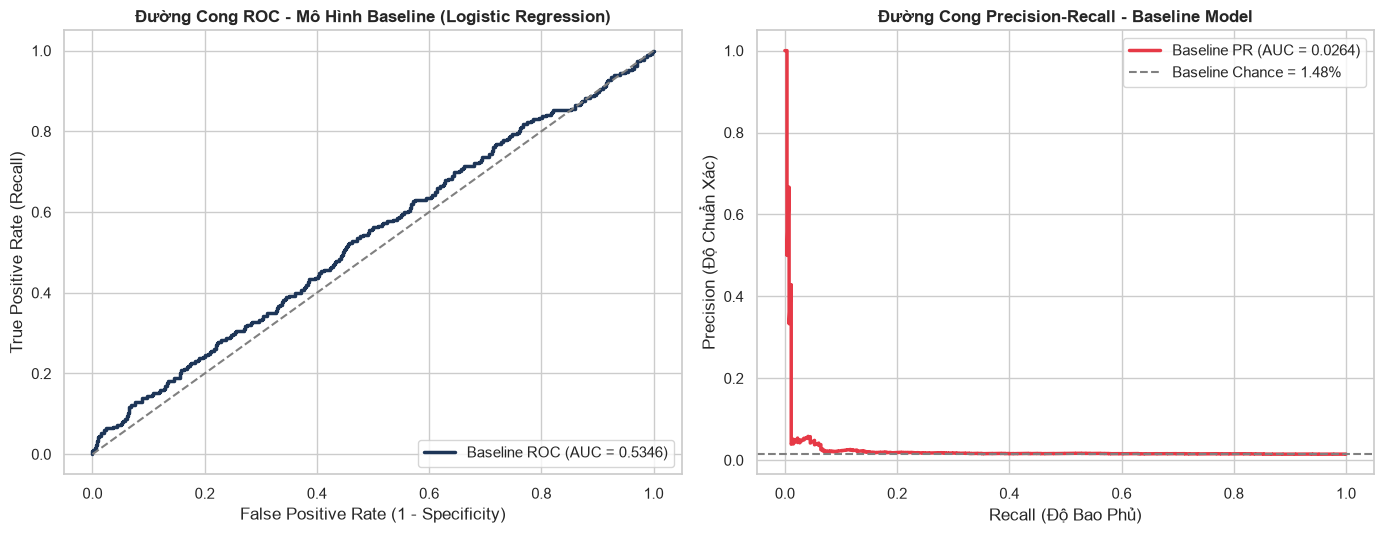

=== CONFUSION MATRIX TẬP TEST (N = 17,950) ===
TN (Bắt đúng Churn):  9,600
FP (Báo nhầm Retain): 8,085
FN (Bỏ sót Retain):   126
TP (Bắt đúng Retain): 139


In [6]:
# Ve bieu do ROC & PR Curve
y_prob = best_artifacts['y_prob']
y_pred = best_artifacts['y_pred']

fpr, tpr, _ = roc_curve(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#1d3557', lw=2.5, label=f'Baseline ROC (AUC = {best_artifacts["metrics"]["roc_auc"]:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('Đường Cong ROC - Mô Hình Baseline (Logistic Regression)', fontweight='bold')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc='lower right')

# PR Curve
axes[1].plot(recall, precision, color='#e63946', lw=2.5, label=f'Baseline PR (AUC = {best_artifacts["metrics"]["pr_auc"]:.4f})')
axes[1].axhline(np.mean(y_test), color='gray', linestyle='--', label=f'Baseline Chance = {np.mean(y_test):.2%}')
axes[1].set_title('Đường Cong Precision-Recall - Baseline Model', fontweight='bold')
axes[1].set_xlabel('Recall (Độ Bao Phủ)')
axes[1].set_ylabel('Precision (Độ Chuẩn Xác)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('baseline_roc_pr_curves.png', dpi=300)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"=== CONFUSION MATRIX TẬP TEST (N = {len(y_test):,}) ===")
print(f"TN (Bắt đúng Churn):  {cm[0,0]:,}")
print(f"FP (Báo nhầm Retain): {cm[0,1]:,}")
print(f"FN (Bỏ sót Retain):   {cm[1,0]:,}")
print(f"TP (Bắt đúng Retain): {cm[1,1]:,}")
